In [104]:
import pandas as pd
from tqdm import notebook
import numpy as np
import re
import os

# Bring Data

In [14]:
yf = pd.read_excel('Voicephishing data_5(Number of Unique Contact)_anonymized.xlsx', dtype={'Phone number':str})

NF = pd.read_excel('Real normal data_1(Number of Unique Contact)_anonymized.xlsx', dtype={'Phone number':str})

# Drawing Discriptive DATA

In [15]:
temp_yf = yf.copy()
temp_NF = NF.copy()

# Select variables to analyze (excluding categorical 'Carrier')
columns_to_describe = [
    'Number of calls (1 week)', 'Day of the week score',
    'Daytime call ratio', 'Smaller than 30sec ratio', 'Outgoing ratio', 'Number of Unique Contacts (1 week)'
]

# Calculate descriptive statistics
desc_yf = temp_yf[columns_to_describe].agg(['mean', 'std']).T
desc_nf = temp_NF[columns_to_describe].agg(['mean', 'std']).T

# Combine into one table
desc_table = pd.concat([desc_yf, desc_nf], axis=1)
desc_table.columns = ['Voice phishing Mean', 'Voice phishing SD', 'Normal Mean', 'Normal SD']

# Format to match academic table style
desc_table = desc_table[['Voice phishing Mean', 'Voice phishing SD', 'Normal Mean', 'Normal SD']]

desc_table

,Voice phishing Mean,Voice phishing SD,Normal Mean,Normal SD
Number of calls (1 week),168.082838,189.042677,139.611111,143.676157
Day of the week score,0.919117,0.134958,0.605880,0.141353
Daytime call ratio,0.896254,0.135015,0.550843,0.182096
Smaller than 30sec ratio,0.457411,0.177474,0.412393,0.150979
Outgoing ratio,0.801887,0.154564,0.585646,0.154754
Number of Unique Contacts (1 week),89.624133,86.036884,14.815288,29.170223


In [17]:
# Categorical Variable percentage

# Voicephishing
voice_carrier_df = pd.DataFrame(temp_yf['Carrier'].value_counts())
voice_total = voice_carrier_df['count'].sum()
voice_carrier_df[''] = voice_carrier_df['count'].apply(lambda x : round((x/voice_total)*100,1))
voice_carrier_df.columns = ['Count', 'Ratio']
voice_carrier_df

,Count,Ratio
Carrier,,
MVNO,2511,93.3
KT,74,2.7
LGU+,66,2.5
SKT,41,1.5


In [18]:
# Normal
normal_carrier_df = pd.DataFrame(temp_NF['Carrier'].value_counts())
normal_total =normal_carrier_df['count'].sum()
normal_carrier_df['Ratio'] = normal_carrier_df['count'].apply(lambda x : round((x/normal_total)*100,1))
normal_carrier_df

,count,Ratio
Carrier,,
SKT,45,41.7
KT,33,30.6
LGU+,22,20.4
MVNO,8,7.4


# Bootstrap(logistic regression)

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [31]:
english_cols = ['Phone number', 'Number of calls (1 week)', 'Day of the week score', 'Daytime call ratio', 'Carrier','Carrier Score','Smaller than 30sec ratio', 
 'Outgoing ratio', 'Number of Unique Contacts (1 week)', 'Label']
new_cols = ['Phone number', 'Number of calls (1 week)', 'Day of the week score', 'Daytime call ratio', 'Smaller than 30sec ratio', 
            'Outgoing ratio', 'Number of Unique Contacts (1 week)','KT','LGU+','MVNO','Label']

In [32]:
# Define stepwise variables
stepwise_vars_ordered = [
    'Number of calls (1 week)',
    'Day of the week score',
    'Daytime call ratio',
    'Smaller than 30sec ratio',
    'Outgoing ratio',
    'Number of Unique Contacts (1 week)'
]
carrier_dummies = ['KT', 'LGU+', 'MVNO']

In [33]:
bootstrap = 1000

In [34]:
import statsmodels.api as sm
results = []
for _ in notebook.tqdm(range(bootstrap), desc='bootstrap') :
    # Total_df = pd.DataFrame()
    random_numbers_to_extract = np.random.choice(range(0, len(yf)), size=len(NF)*9, replace=False)
    final_yf = yf.loc[random_numbers_to_extract,:]
    final_yf.reset_index(drop=True, inplace=True)
    final_yf['Label'] = 1
    NF['Label'] = 0
    Final_yf = pd.concat([final_yf,NF], ignore_index=True)
    Final_yf.columns = english_cols
    Final_yf['Carrier'] = pd.Categorical(Final_yf['Carrier'], categories=['SKT', 'KT', 'LGU+', 'MVNO'], ordered=True)
    dummies = pd.get_dummies(Final_yf['Carrier'], drop_first=True)
    Final_yf = pd.concat([Final_yf, dummies], axis=1)
    Final_yf = Final_yf.drop(['Carrier','Carrier Score'], axis=1)
    Final_yf['Label2'] = Final_yf['Label']
    Final_yf = Final_yf.drop(columns='Label')
    Final_yf = Final_yf.rename(columns={'Label2':'Label'})
    data = Final_yf.copy()
    exclude_columns = ["Phone number", "KT", "LGU+", "MVNO", "Label"]
    # Separate columns to be standardized and excluded
    columns_to_standardize = [col for col in data.columns if col not in exclude_columns]
    columns_to_exclude = data[exclude_columns]
    # Standardize the selected columns
    scaler = StandardScaler()
    standardized_data = scaler.fit_transform(data[columns_to_standardize])
    # Convert standardized data back to DataFrame
    standardized_df = pd.DataFrame(standardized_data, columns=columns_to_standardize)
    # Combine excluded columns with standardized data
    test = pd.concat([columns_to_exclude, standardized_df], axis=1)
    Final_yf = test[new_cols]
    data = Final_yf.copy()
    # X = data.loc[:, "Number of calls (1 week)":"MVNO"]
    y = data["Label"]
    stepwise_result = {'Order': f'{_}', 'Step': 0, 'AIC': None}
    X_const = sm.add_constant(pd.DataFrame(index=data.index))
    model = sm.Logit(y, X_const).fit(disp=0)
    stepwise_result.update(model.params.to_dict())
    stepwise_result['AIC'] = model.aic
    stepwise_result['Variables'] = []
    results.append(stepwise_result)
    data['KT'] = data['KT'].astype(int)
    data['LGU+'] = data['LGU+'].astype(int)
    data['MVNO'] = data['MVNO'].astype(int)
    for i in range(1, len(stepwise_vars_ordered) + 1):
        current_vars = stepwise_vars_ordered[:i]
        X = sm.add_constant(data[current_vars])
        try:
            model = sm.Logit(y, X).fit(disp=0)
            result = {
                'Order': f'{_}',
                'Step': i,
                'AIC': model.aic,
                'Variables': current_vars
            }
            result.update(model.params.to_dict())
            results.append(result)
        except np.linalg.LinAlgError:
            print(f"Skipping step {i} due to singular matrix.")
            continue
    
    # Final step: add all carrier dummies together
    final_vars = stepwise_vars_ordered + carrier_dummies
    X = sm.add_constant(data[final_vars])
    try:
        model = sm.Logit(y, X).fit(disp=0)
        result = {
            'Order': f'{_}',
            'Step': len(stepwise_vars_ordered) + 1,
            'AIC': model.aic,
            'Variables': final_vars
        }
        result.update(model.params.to_dict())
        results.append(result)
    except np.linalg.LinAlgError:
        print(f"Skipping final model due to singular matrix.")
        # continue

bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

In [36]:
# Convert to DataFrame
stepwise_df = pd.DataFrame(results)

In [49]:
noerror_carrer = stepwise_df[stepwise_df['Step']==7]
noerror_order_list = list(noerror_carrer['Order'])[:1000]  # 1000개
stepwise_df1 = pd.DataFrame()
for order in noerror_order_list :
    temp = stepwise_df[stepwise_df['Order'] == order]
    stepwise_df1 = pd.concat([stepwise_df1, temp])
stepwise_df1.reset_index(drop=True, inplace=True)
stepwise_df1 = stepwise_df1.drop(columns='Order')
# stepwise_df1.to_excel('stepwise_df.xlsx', index=False)

In [50]:
# Drop unnecessary columns if any (keeping only numeric and variable-related ones)
numeric_cols = stepwise_df1.select_dtypes(include=[np.number]).columns
numeric_cols = list(numeric_cols)
numeric_cols.remove('Step')

In [51]:
# Group by 'Step' and calculate mean, std, and count for each variable
summary = stepwise_df1.groupby('Step')[numeric_cols].agg(['mean', 'std'])
summary

AIC                const           Number of calls (1 week)  \
            mean        std      mean       std                     mean   
Step                                                                       
0     704.179223   0.000000  2.197225  0.000000                      NaN   
1     703.346946   0.770309  2.212167  0.004576                 0.207930   
2     439.926744  14.478334  3.193582  0.073781                -0.016073   
3     392.350344  12.797939  3.477058  0.070905                -0.165271   
4     379.481676  13.442086  3.513145  0.072969                -0.199272   
5     364.354400  13.355408  3.617437  0.073984                -0.282846   
6     356.647138  12.529694  4.075142  0.086946                -0.472701   
7     271.717591  11.246767  0.530339  0.249610                -0.374308   

               Day of the week score           Daytime call ratio            \
           std                  mean       std               mean       std   
Step                                                                          
0          NaN                   NaN       NaN                NaN       NaN   
1     0.035233                   NaN       NaN                NaN       NaN   
2     0.053246              1.532215  0.056234                NaN       NaN   
3     0.044941              0.839619  0.093340           1.030180  0.099117   
4     0.057924              0.841704  0.093245           1.060735  0.098395   
5     0.053519              0.577532  0.105073           1.108797  0.100568   
6     0.089018              0.517229  0.107935           0.931447  0.102778   
7     0.065563              0.132465  0.141972           0.865335  0.129066   

      ... Outgoing ratio           Number of Unique Contacts (1 week)  \
      ...           mean       std                               mean   
Step  ...                                                               
0     ...            NaN       NaN                                NaN   
1     ...            NaN       NaN                                NaN   
2     ...            NaN       NaN                                NaN   
3     ...            NaN       NaN                                NaN   
4     ...            NaN       NaN                                NaN   
5     ...       0.524931  0.060538                                NaN   
6     ...       0.392869  0.065189                           1.344768   
7     ...      -0.033524  0.108481                           0.447686   

                      KT                LGU+                MVNO            
           std      mean       std      mean       std      mean       std  
Step                                                                        
0          NaN       NaN       NaN       NaN       NaN       NaN       NaN  
1          NaN       NaN       NaN       NaN       NaN       NaN       NaN  
2          NaN       NaN       NaN       NaN       NaN       NaN       NaN  
3          NaN       NaN       NaN       NaN       NaN       NaN       NaN  
4          NaN       NaN       NaN       NaN       NaN       NaN       NaN  
5          NaN       NaN       NaN       NaN       NaN       NaN       NaN  
6     0.195390       NaN       NaN       NaN       NaN       NaN       NaN  
7     0.162593  0.762864  0.291708  1.533724  0.274939  4.458624  0.247786  

[8 rows x 22 columns]

In [56]:
result_df_mean = pd.DataFrame()
result_df_std = pd.DataFrame()
multicols = list(summary.columns)
for first_col, second_col in multicols :
    if second_col == 'mean' :
        result_df_mean[first_col] = summary[(first_col,second_col)]
    elif second_col == 'std' :
        result_df_std[first_col] = summary[(first_col,second_col)]

In [57]:
result_df = pd.DataFrame()
num = 0
cols = list(result_df_mean.columns)
for i in range(len(result_df_mean)) :
    for col in cols :
        mean_value = result_df_mean.loc[i, col]
        std_value = result_df_std.loc[i, col]
        mean_value = round(mean_value,3)
        std_value = round(std_value,3)
        final_value = f'{mean_value}\n({std_value})'
        result_df.loc[num, col] = final_value
    num = num+1

In [58]:
for col in cols :
    result_df[col] = result_df[col].apply(lambda x : x.replace('nan\n(nan)',''))

In [59]:
Model_names = [f'Model{i+1}' for i in range(len(result_df))]
try : result_df.insert(0, 'Model', Model_names)
except : pass

In [60]:
result_df_T = result_df.T
result_df_T.columns = list(result_df_T.loc['Model'])
result_df_T_indexes = numeric_cols[2:] + numeric_cols[1:2] + numeric_cols[0:1]
result_df_T = result_df_T.loc[result_df_T_indexes,:]
result_df_T

,Model1,Model2,Model3,Model4,Model5,Model6,Model7,Model8
Number of calls (1 week),,0.208\n(0.035),-0.016\n(0.053),-0.165\n(0.045),-0.199\n(0.058),-0.283\n(0.054),-0.473\n(0.089),-0.374\n(0.066)
Day of the week score,,,1.532\n(0.056),0.84\n(0.093),0.842\n(0.093),0.578\n(0.105),0.517\n(0.108),0.132\n(0.142)
Daytime call ratio,,,,1.03\n(0.099),1.061\n(0.098),1.109\n(0.101),0.931\n(0.103),0.865\n(0.129)
Smaller than 30sec ratio,,,,,0.509\n(0.091),0.444\n(0.088),0.356\n(0.09),0.387\n(0.11)
Outgoing ratio,,,,,,0.525\n(0.061),0.393\n(0.065),-0.034\n(0.108)
Number of Unique Contacts (1 week),,,,,,,1.345\n(0.195),0.448\n(0.163)
KT,,,,,,,,0.763\n(0.292)
LGU+,,,,,,,,1.534\n(0.275)
MVNO,,,,,,,,4.459\n(0.248)
const,2.197\n(0.0),2.212\n(0.005),3.194\n(0.074),3.477\n(0.071),3.513\n(0.073),3.617\n(0.074),4.075\n(0.087),0.53\n(0.25)


In [61]:
# result_df_T.to_excel('Stepwise_model_T results250530.xlsx')

In [65]:
# Import missing module
from scipy import stats
file_path = 'Stepwise_model_T results250530.xlsx'
xls = pd.ExcelFile(file_path)
# Check sheet names and load the relevant one
sheet_names = xls.sheet_names
df_pvalue = xls.parse(sheet_names[0])
# Clean up and extract coefficient and standard deviation using regex
def extract_coef_and_std(cell):
    if isinstance(cell, str):
        match = re.match(r"(-?\d+\.\d+)\s*\((\d+\.\d+)\)", cell)
        if match:
            return float(match.group(1)), float(match.group(2))
    return None, None
# Initialize new DataFrame
columns = df_pvalue.columns
processed_data = []
for idx, row in df_pvalue.iterrows():
    new_row = {"Variable": row.iloc[0]}
    # print(idx, row)
    for col in columns[1:]:
        # Skip AIC column from significance marking
        if idx == 10:
            new_row[col] = row[col]
            continue

        coef, std = extract_coef_and_std(row[col])
        if coef is not None and std is not None and std != 0:
            z_score = coef / std
            p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))
            if p_value < 0.001:
                sig = "***"
            elif p_value < 0.01:
                sig = "**"
            elif p_value < 0.05:
                sig = "*"
            else:
                sig = ""
            new_row[col] = f"{coef:.3f}{sig} ({std:.3f})"
        else:
            new_row[col] = row[col]
    processed_data.append(new_row)

# Convert to DataFrame
processed_df = pd.DataFrame(processed_data)
processed_df

,Variable,Model1,Model2,Model3,Model4,Model5,Model6,Model7,Model8
0,Number of calls (1 week),NaN,0.209*** (0.036),-0.017 (0.056),-0.166*** (0.047),-0.200*** (0.059),-0.282*** (0.053),-0.473*** (0.089),-0.373*** (0.063)
1,Day of the week score,NaN,NaN,1.532*** (0.057),0.842*** (0.089),0.842*** (0.091),0.579*** (0.103),0.519*** (0.107),0.130 (0.148)
2,Daytime call ratio,NaN,NaN,NaN,1.026*** (0.095),1.057*** (0.095),1.105*** (0.097),0.926*** (0.098),0.865*** (0.122)
3,Smaller than 30sec ratio,NaN,NaN,NaN,NaN,0.507*** (0.089),0.441*** (0.087),0.355*** (0.088),0.388*** (0.107)
4,Outgoing ratio,NaN,NaN,NaN,NaN,NaN,0.522*** (0.061),0.390*** (0.065),-0.036 (0.107)
5,Number of Unique Contacts (1 week),NaN,NaN,NaN,NaN,NaN,NaN,1.348*** (0.196),0.446** (0.158)
6,KT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.788** (0.282)
7,LGU+,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.555*** (0.271)
8,MVNO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.481*** (0.255)
9,const,2.197\n(0.0),2.212*** (0.005),3.193*** (0.075),3.474*** (0.074),3.509*** (0.077),3.613*** (0.079),4.071*** (0.093),0.508 (0.263)


# Machine learning Models

In [69]:

# 1. Import required libraries
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Random_forest_list = []
Gradient_boosting_list = []
MLP_list = []
Logistic_list = []

for _ in notebook.tqdm(range(1000), desc='bootstrap'):
    # -----------------------------
    # 1) Bootstrap sample generation
    # -----------------------------
    random_numbers_to_extract = np.random.choice(
        range(0, len(yf)),
        size=len(NF) * 9,
        replace=False
    )

    final_yf = yf.loc[random_numbers_to_extract, :].copy()
    final_yf.reset_index(drop=True, inplace=True)
    final_yf['Label'] = 1

    nf_tmp = NF.copy()
    nf_tmp['Label'] = 0

    Final_yf = pd.concat([final_yf, nf_tmp], ignore_index=True)
    Final_yf.columns = english_cols

    Final_yf['Carrier'] = pd.Categorical(
        Final_yf['Carrier'],
        categories=['SKT', 'KT', 'LGU+', 'MVNO'],
        ordered=True
    )

    dummies = pd.get_dummies(Final_yf['Carrier'], drop_first=True)
    Final_yf = pd.concat([Final_yf, dummies], axis=1)

    Final_yf = Final_yf.drop(['Carrier', 'Carrier Score'], axis=1, errors='ignore')

    Final_yf['Label2'] = Final_yf['Label']
    Final_yf = Final_yf.drop(columns='Label')
    Final_yf = Final_yf.rename(columns={'Label2': 'Label'})

    # -----------------------------
    # 2) X, y split
    # -----------------------------
    y = Final_yf["Label"]
    X = Final_yf.drop(columns=["Label", "Phone number", "Carrier Score"], errors='ignore').copy()

    # -----------------------------
    # 3) Train / Test split
    # -----------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.3,
        stratify=y,
        random_state=42
    )

    # -----------------------------
    # 4) Standardization
    #    - Fit only continuous variables based on the training set
    # -----------------------------
    continuous_cols = [
        'Number of calls (1 week)',
        'Day of the week score',
        'Daytime call ratio',
        'Smaller than 30sec ratio',
        'Outgoing ratio',
        'Number of Unique Contacts (1 week)'
    ]

    scaler = StandardScaler()
    X_train = X_train.copy()
    X_test = X_test.copy()

    X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
    X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

    # Ensure dummy variables are stored as integers
    for col in ['KT', 'LGU+', 'MVNO']:
        if col in X_train.columns:
            X_train[col] = X_train[col].astype(int)
            X_test[col] = X_test[col].astype(int)

    # -----------------------------
    # 5) Logistic Regression baseline
    # -----------------------------
    logit_model = LogisticRegression(
        solver='liblinear',
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    )
    logit_model.fit(X_train, y_train)
    y_pred_logit = logit_model.predict(X_test)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_logit).ravel()
    report_logit = classification_report(y_test, y_pred_logit, output_dict=True)

    Logistic_list.append({
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp,
        'Accuracy': round(report_logit['accuracy'], 3),
        'Precision of class1': round(report_logit['1']['precision'], 3),
        'Recall of class1': round(report_logit['1']['recall'], 3),
        'F1-score': round(report_logit['1']['f1-score'], 3)
    })

    # -----------------------------
    # 6) Random Forest
    # -----------------------------
    rf_model = RandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42
    )

    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    report = classification_report(y_test, y_pred, output_dict=True)

    Random_forest_list.append({
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp,
        'Accuracy': round(report['accuracy'], 3),
        'Precision of class1': round(report['1']['precision'], 3),
        'Recall of class1': round(report['1']['recall'], 3),
        'F1-score': round(report['1']['f1-score'], 3)
    })

    # -----------------------------
    # 7) Gradient Boosting
    # -----------------------------
    gb_model = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        min_samples_leaf=1,
        subsample=0.7,
        random_state=42
    )

    gb_model.fit(X_train, y_train)
    y_pred_gb = gb_model.predict(X_test)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_gb).ravel()
    report_gb = classification_report(y_test, y_pred_gb, output_dict=True)

    Gradient_boosting_list.append({
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp,
        'Accuracy': round(report_gb['accuracy'], 3),
        'Precision of class1': round(report_gb['1']['precision'], 3),
        'Recall of class1': round(report_gb['1']['recall'], 3),
        'F1-score': round(report_gb['1']['f1-score'], 3)
    })

    # -----------------------------
    # 8) Multi-layer Perceptron
    # -----------------------------
    mlp_model = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    )

    mlp_model.fit(X_train, y_train)
    y_pred_mlp = mlp_model.predict(X_test)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_mlp).ravel()
    report_mlp = classification_report(y_test, y_pred_mlp, output_dict=True)

    MLP_list.append({
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp,
        'Accuracy': round(report_mlp['accuracy'], 3),
        'Precision of class1': round(report_mlp['1']['precision'], 3),
        'Recall of class1': round(report_mlp['1']['recall'], 3),
        'F1-score': round(report_mlp['1']['f1-score'], 3)
    })

# -----------------------------
# 9) Organize DataFrames
# -----------------------------
Logistic_df = pd.DataFrame(Logistic_list)
Random_forest_df = pd.DataFrame(Random_forest_list)
Gradient_boosting_df = pd.DataFrame(Gradient_boosting_list)
MLP_df = pd.DataFrame(MLP_list)

bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

C:\Users\user\venvs\Dissertation\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:792: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
C:\Users\user\venvs\Dissertation\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:792: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
C:\Users\user\venvs\Dissertation\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:792: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")

KeyboardInterrupt



KeyboardInterrupt: 

In [ ]:
# Random_forest_df
summary_stats = Random_forest_df.describe().loc[['mean', 'std']].T
summary_stats.columns = ['Mean', 'Standard Deviation']
summary_stats.reset_index(inplace=True)
summary_stats.rename(columns={'index': 'Metric'}, inplace=True)
for i in range(4) :
    summary_stats.at[i,"Mean"] = round(summary_stats.at[i,"Mean"],1)
    summary_stats.at[i,"Standard Deviation"] = round(summary_stats.at[i,"Standard Deviation"],1)

MLP_summary_stats = MLP_df.describe().loc[['mean', 'std']].T
MLP_summary_stats.columns = ['Mean', 'Standard Deviation']
MLP_summary_stats.reset_index(inplace=True)
MLP_summary_stats.rename(columns={'index': 'Metric'}, inplace=True)
for i in range(4) :
    MLP_summary_stats.at[i,"Mean"] = round(MLP_summary_stats.at[i,"Mean"],1)
    MLP_summary_stats.at[i,"Standard Deviation"] = round(MLP_summary_stats.at[i,"Standard Deviation"],1)

Gradient_boosting_summary_stats = Gradient_boosting_df.describe().loc[['mean', 'std']].T
Gradient_boosting_summary_stats.columns = ['Mean', 'Standard Deviation']
Gradient_boosting_summary_stats.reset_index(inplace=True)
Gradient_boosting_summary_stats.rename(columns={'index': 'Metric'}, inplace=True)
for i in range(4) :
    Gradient_boosting_summary_stats.at[i,"Mean"] = round(Gradient_boosting_summary_stats.at[i,"Mean"],1)
    Gradient_boosting_summary_stats.at[i,"Standard Deviation"] = round(Gradient_boosting_summary_stats.at[i,"Standard Deviation"],1)

Logistic_summary_stats = Logistic_df.describe().loc[['mean', 'std']].T
Logistic_summary_stats.columns = ['Mean', 'Standard Deviation']
Logistic_summary_stats.reset_index(inplace=True)
Logistic_summary_stats.rename(columns={'index': 'Metric'}, inplace=True)
for i in range(4) :
    Logistic_summary_stats.at[i,"Mean"] = round(Logistic_summary_stats.at[i,"Mean"],1)
    Logistic_summary_stats.at[i,"Standard Deviation"] = round(Logistic_summary_stats.at[i,"Standard Deviation"],1)

In [ ]:
# summary_stats.to_excel('Randomforest_summary_stats.xlsx', index=False)
# Gradient_boosting_summary_stats.to_excel('Gradient_boosting_summary_stats.xlsx', index=False)
# MLP_summary_stats.to_excel('MLP_summary_stats.xlsx', index=False)
# Logistic_summary_stats.to_excel('Logistic_summary_stats.xlsx', index=False)

In [70]:
# Reload the uploaded Excel files after code execution state reset
rf_df = pd.read_excel("Randomforest_summary_stats.xlsx")
gb_df = pd.read_excel("Gradient_boosting_summary_stats.xlsx")
mlp_df = pd.read_excel("MLP_summary_stats.xlsx")
Logistic_df = pd.read_excel("Logistic_summary_stats.xlsx")

In [71]:
# Combine all models into a single summary table with pivoted format
summary_df = pd.DataFrame({
    'Metric': rf_df['Metric'],
    'Random Forest (Mean ± SD)': rf_df['Mean'].round(3).astype(str) + ' ± ' + rf_df['Standard Deviation'].round(3).astype(str),
    'Gradient Boosting (Mean ± SD)': gb_df['Mean'].round(3).astype(str) + ' ± ' + gb_df['Standard Deviation'].round(3).astype(str),
    'MLP (Mean ± SD)': mlp_df['Mean'].round(3).astype(str) + ' ± ' + mlp_df['Standard Deviation'].round(3).astype(str),
    'Logistic (Mean ± SD)': Logistic_df['Mean'].round(3).astype(str) + ' ± ' + Logistic_df['Standard Deviation'].round(3).astype(str)
})

In [72]:
summary_df

,Metric,Random Forest (Mean ± SD),Gradient Boosting (Mean ± SD),MLP (Mean ± SD),Logistic (Mean ± SD)
0,TN,27.1 ± 1.0,25.9 ± 1.4,21.3 ± 2.2,28.0 ± 0.0
1,FP,4.9 ± 1.0,6.1 ± 1.4,10.7 ± 2.2,4.0 ± 0.0
2,FN,5.3 ± 2.2,4.9 ± 2.2,7.7 ± 2.8,20.7 ± 4.3
3,TP,286.7 ± 2.2,287.1 ± 2.2,284.3 ± 2.8,271.3 ± 4.3
4,Accuracy,0.969 ± 0.007,0.966 ± 0.007,0.943 ± 0.01,0.924 ± 0.013
5,Precision of class1,0.983 ± 0.003,0.979 ± 0.005,0.964 ± 0.007,0.985 ± 0.001
6,Recall of class1,0.982 ± 0.008,0.983 ± 0.008,0.974 ± 0.009,0.929 ± 0.015
7,F1-score,0.983 ± 0.004,0.981 ± 0.004,0.969 ± 0.006,0.956 ± 0.008


# Detailed Machine Learning Models Experiments

## Template for saving/loading (recommended: ColumnTransformer + Pipeline)

In [74]:
NF = NF.drop(columns = 'Carrier Score')

In [85]:
yf = yf.drop(columns = 'Carrier Score')

In [76]:
import numpy as np
import pandas as pd
from joblib import dump, load

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    learning_curve
)
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

In [77]:
english_cols = ['Phone number', 'Number of calls (1 week)', 'Day of the week score', 'Daytime call ratio',
                'Carrier','Smaller than 30sec ratio', 'Outgoing ratio',
                'Number of Unique Contacts (1 week)', 'Label']

In [78]:
def make_Final_yf(yf, NF, english_cols, sample_ratio=9, seed=None):
    """
    yf: positive pool
    NF: negative pool (full)
    sample_ratio: Positive-to-negative ratio (e.g., if 9, sample positives at 9 times the number of negatives)
    seed: reproducibility
    """
    rng = np.random.default_rng(seed)

    # 1) Extract samples from yf
    n_pos = len(NF) * sample_ratio
    n_pos = int(round(n_pos,0))
    idx = rng.choice(len(yf), size=n_pos, replace=False)
    final_yf = yf.iloc[idx].copy()
    final_yf.reset_index(drop=True, inplace=True)

    # 2) Labeling + concatenation
    final_yf["Label"] = 1
    NF2 = NF.copy()
    NF2["Label"] = 0

    Final_yf = pd.concat([final_yf, NF2], ignore_index=True)
    Final_yf.columns = english_cols
    Final_yf['Daytime call ratio'] = Final_yf['Daytime call ratio'].fillna(0)

    return Final_yf

### (A) Function to create a common preprocessing + model pipeline

In [80]:
def build_preprocessor_from_X(X: pd.DataFrame):
    
    drop_cols = ["Phone number"]  

    categorical_features = ["Carrier"]

    numeric_features = [
        c for c in X.columns
        if (c not in drop_cols) and (c not in categorical_features)
    ]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), numeric_features),
            ("cat", OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                categories=[["SKT", "KT", "LGU+", "MVNO"]]
            ), categorical_features),
        ],
        remainder="drop"
    )
    return preprocessor, numeric_features

def build_pipeline(X: pd.DataFrame, model):
    """### [NEW] Responsible only for creating the pipeline (fit separately)"""
    preprocessor, numeric_cols = build_preprocessor_from_X(X)
    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])
    return pipe, numeric_cols

def summarize_metrics(y_true, y_pred):
    """[NEW] Standardize the metric dictionary"""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_pos": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_pos": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_pos": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
    }

def plot_learning_curve_for_pipeline(pipe, X, y, cv, scoring="f1", train_sizes=np.linspace(0.1, 1.0, 8)):
    """### [NEW] Visualize the training curve (= learning curve): Check performance saturation as the data size increases"""
    sizes, train_scores, valid_scores = learning_curve(
        estimator=pipe,
        X=X,
        y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    valid_mean = valid_scores.mean(axis=1)
    valid_std = valid_scores.std(axis=1)

    plt.figure()
    plt.plot(sizes, train_mean, marker="o", label="Train")
    plt.fill_between(sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
    plt.plot(sizes, valid_mean, marker="o", label="CV Valid")
    plt.fill_between(sizes, valid_mean - valid_std, valid_mean + valid_std, alpha=0.2)
    plt.xlabel("Training samples")
    plt.ylabel(scoring)
    plt.title(f"Learning Curve ({scoring})")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_cv_ci(cv_results, metric_key="test_f1"):
    """
    ### [NEW] Visualize confidence intervals (CI) based on CV results
    - Display the mean of fold scores and the 95% CI(normal approximation: mean ± 1.96 * SE)
    """
    scores = cv_results[metric_key]
    k = len(scores)
    mean = float(np.mean(scores))
    std = float(np.std(scores, ddof=1)) if k > 1 else 0.0
    se = std / np.sqrt(k) if k > 1 else 0.0
    ci_low = mean - 1.96 * se
    ci_high = mean + 1.96 * se

    # 점 분포 + 평균/CI
    plt.figure()
    plt.scatter(np.arange(1, k + 1), scores)
    plt.axhline(mean, linestyle="--")
    plt.axhline(ci_low, linestyle=":")
    plt.axhline(ci_high, linestyle=":")
    plt.xlabel("Fold")
    plt.ylabel(metric_key)
    model_name = "Random Forest"
    plt.title(
    f"{model_name} – Cross-Validation Scores with 95% CI\n"
    f"mean={mean:.3f}, CI=[{ci_low:.3f}, {ci_high:.3f}]"
    )
    # plt.title(f"Cross-Validation Scores with 95% CI\nmean={mean:.3f}, CI=[{ci_low:.3f}, {ci_high:.3f}]")
    plt.tight_layout()
    plt.show()

## Train and save final models (RF/GB/MLP available respectively)

### (B) Train and save directly from the raw dataframe (original columns)

In [88]:
def fit_and_save_final_model(raw_df: pd.DataFrame, model, save_path: str):
    global cv_results
    """
    ### [CHANGED]
    - (1) Train/Valid split
    - (2) Cross-validation + 95% CI plot
    - (3) Learning curve plot (checking saturation)
    - (4) Refit the final model on the full dataset and save it
    """
    raw_df = raw_df.sample(frac=1, random_state=42).reset_index(drop=True)
    y = raw_df["Label"].astype(int)
    X = raw_df.drop(columns=["Label"])

    # -----------------------------
    # ### [NEW] 1) Train/Valid split
    # -----------------------------
    X_train, X_valid, y_train, y_valid = train_test_split(
        X, y,
        test_size=0.3,
        random_state=42,
        stratify=y
    )

    pipe, numeric_cols = build_pipeline(X_train, model)

    # Train fit
    pipe.fit(X_train, y_train)

    # Validation evaluation
    valid_pred = pipe.predict(X_valid)
    valid_metrics = summarize_metrics(y_valid, valid_pred)

    print("=== Hold-out Validation Metrics (30%) ===")
    print({k: round(v, 4) for k, v in valid_metrics.items()})
    print("Confusion Matrix:\n", confusion_matrix(y_valid, valid_pred))
    print(classification_report(y_valid, valid_pred, digits=4))

    # --------------------------------------
    # ### [NEW] 2) Cross-validation + CI
    # --------------------------------------
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    cv_results = cross_validate(
        estimator=pipe,
        X=X,
        y=y,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "precision": "precision",
            "recall": "recall",
            "f1": "f1"
        },
        return_train_score=False,
        n_jobs=-1
    )

    print("\n=== 5-Fold CV (mean ± std) ===")
    for key in ["test_accuracy", "test_precision", "test_recall", "test_f1"]:
        mean = cv_results[key].mean()
        std = cv_results[key].std()
        print(f"{key}: {mean:.4f} ± {std:.4f}")

    # ### [NEW] Visualize the 95% CI (Change metric_key if you want to plot precision/recall as well)
    plot_cv_ci(cv_results, metric_key="test_f1")

    # --------------------------------------
    # ### [NEW] 3) Learning curve (saturation)
    # --------------------------------------
    # Since learning_curve internally fits the estimator multiple times,
    #  you can pass the pipeline as-is even if it has already been fitted(it will be retrained internally).
    plot_learning_curve_for_pipeline(pipe, X, y, cv=cv, scoring="f1")

    # --------------------------------------
    # ### [CHANGED] 4) Final save: retrain on the full dataset before saving
    # --------------------------------------
    final_pipe, _ = build_pipeline(X, model)
    final_pipe.fit(X, y)

    try:
        feature_names = final_pipe.named_steps["preprocess"].get_feature_names_out().tolist()
    except Exception:
        feature_names = None

    payload = {
        "pipeline": final_pipe,
        "raw_columns": X.columns.tolist(),
        "numeric_cols": numeric_cols,
        "feature_names": feature_names,
        "holdout_valid_metrics": valid_metrics,
        "cv_results_summary": {
            k: (float(np.mean(v)), float(np.std(v)))
            for k, v in cv_results.items()
            if k.startswith("test_")
        }
    }

    dump(payload, save_path)
    print(f"\nSaved to: {save_path}")

In [89]:
Final_yf_full = make_Final_yf(yf=yf, NF=NF, english_cols=english_cols, sample_ratio=9, seed=42)
Final_yf_full = Final_yf_full.sample(frac=1, random_state=42).reset_index(drop=True)

### Save RandomForest

=== Hold-out Validation Metrics (30%) ===
{'accuracy': 0.9753, 'precision_pos': 0.9897, 'recall_pos': 0.9829, 'f1_pos': 0.9863}
Confusion Matrix:
 [[ 29   3]
 [  5 287]]
              precision    recall  f1-score   support

           0     0.8529    0.9062    0.8788        32
           1     0.9897    0.9829    0.9863       292

    accuracy                         0.9753       324
   macro avg     0.9213    0.9446    0.9325       324
weighted avg     0.9762    0.9753    0.9756       324


=== 5-Fold CV (mean ± std) ===
test_accuracy: 0.9694 ± 0.0086
test_precision: 0.9836 ± 0.0074
test_recall: 0.9825 ± 0.0095
test_f1: 0.9830 ± 0.0048


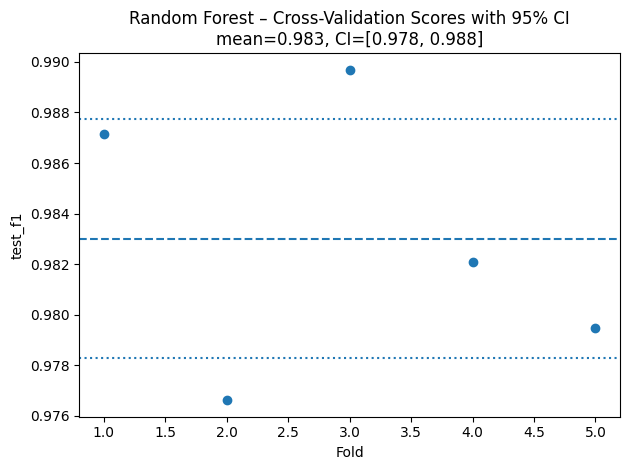

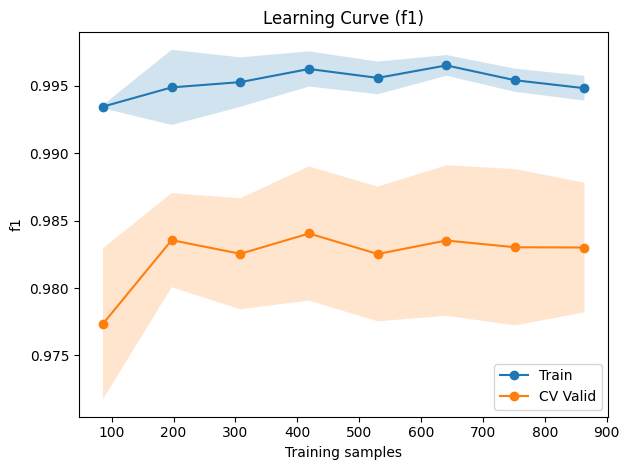


Saved to: rf_final_pipeline.joblib


In [87]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1  # Random Forest supports CPU parallelization
)

fit_and_save_final_model(Final_yf_full, rf_model, "rf_final_pipeline.joblib")

### Save GradientBoosting

In [99]:
def plot_learning_curve_for_pipeline(pipe, X, y, cv, scoring="f1", seed=42):
    # Use the ratio as-is (maximum CV train size is handled automatically)
    train_sizes = np.linspace(0.1, 1.0, 8)

    sizes, train_scores, valid_scores = learning_curve(
        estimator=pipe,
        X=X,
        y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        shuffle=True,          # Fix label alignment issue
        random_state=seed,
        error_score=np.nan     # Prevent crashes even if NaN values appear
    )

    train_mean = np.nanmean(train_scores, axis=1)
    train_std  = np.nanstd(train_scores, axis=1)
    valid_mean = np.nanmean(valid_scores, axis=1)
    valid_std  = np.nanstd(valid_scores, axis=1)

    plt.figure()
    plt.plot(sizes, train_mean, marker="o", label="Train")
    plt.fill_between(sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
    plt.plot(sizes, valid_mean, marker="o", label="CV Valid")
    plt.fill_between(sizes, valid_mean - valid_std, valid_mean + valid_std, alpha=0.2)
    plt.xlabel("Training samples")
    plt.ylabel(scoring)
    plt.title(f"Learning Curve ({scoring})")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [100]:
def plot_cv_ci(cv_results, metric_key="test_f1"):
    """
    ### [NEW] Visualize confidence intervals (CI) based on CV results
    - Display the mean of fold scores and the 95% CI(normal approximation: mean ± 1.96 * SE)
    """
    scores = cv_results[metric_key]
    k = len(scores)
    mean = float(np.mean(scores))
    std = float(np.std(scores, ddof=1)) if k > 1 else 0.0
    se = std / np.sqrt(k) if k > 1 else 0.0
    ci_low = mean - 1.96 * se
    ci_high = mean + 1.96 * se

    # 점 분포 + 평균/CI
    plt.figure()
    plt.scatter(np.arange(1, k + 1), scores)
    plt.axhline(mean, linestyle="--")
    plt.axhline(ci_low, linestyle=":")
    plt.axhline(ci_high, linestyle=":")
    plt.xlabel("Fold")
    plt.ylabel(metric_key)
    model_name = "GradientBoosting"
    plt.title(
    f"{model_name} – Cross-Validation Scores with 95% CI\n"
    f"mean={mean:.3f}, CI=[{ci_low:.3f}, {ci_high:.3f}]"
    )
    # plt.title(f"Cross-Validation Scores with 95% CI\nmean={mean:.3f}, CI=[{ci_low:.3f}, {ci_high:.3f}]")
    plt.tight_layout()
    plt.show()

=== Hold-out Validation Metrics (30%) ===
{'accuracy': 0.9722, 'precision_pos': 0.9863, 'recall_pos': 0.9829, 'f1_pos': 0.9846}
Confusion Matrix:
 [[ 28   4]
 [  5 287]]
              precision    recall  f1-score   support

           0     0.8485    0.8750    0.8615        32
           1     0.9863    0.9829    0.9846       292

    accuracy                         0.9722       324
   macro avg     0.9174    0.9289    0.9231       324
weighted avg     0.9726    0.9722    0.9724       324


=== 5-Fold CV (mean ± std) ===
test_accuracy: 0.9676 ± 0.0101
test_precision: 0.9796 ± 0.0063
test_recall: 0.9846 ± 0.0112
test_f1: 0.9820 ± 0.0057


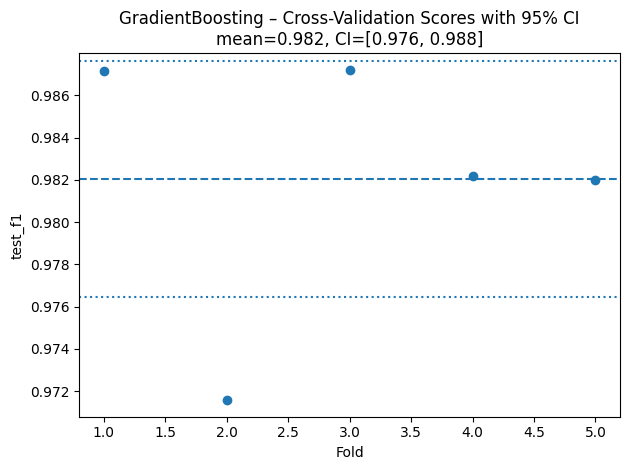

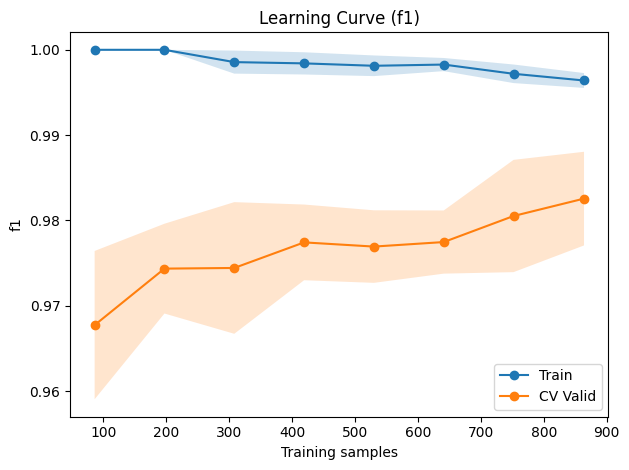


Saved to: gb_final_pipeline.joblib


In [101]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=1,
    subsample=0.7,
    random_state=42
)
fit_and_save_final_model(Final_yf_full, gb_model, "gb_final_pipeline.joblib")

### Save MLP

In [95]:
def plot_cv_ci(cv_results, metric_key="test_f1"):
    """
    ### [NEW] Visualize confidence intervals (CI) based on CV results
    - Display the mean of fold scores and the 95% CI(normal approximation: mean ± 1.96 * SE)
    """
    scores = cv_results[metric_key]
    k = len(scores)
    mean = float(np.mean(scores))
    std = float(np.std(scores, ddof=1)) if k > 1 else 0.0
    se = std / np.sqrt(k) if k > 1 else 0.0
    ci_low = mean - 1.96 * se
    ci_high = mean + 1.96 * se

    # 점 분포 + 평균/CI
    plt.figure()
    plt.scatter(np.arange(1, k + 1), scores)
    plt.axhline(mean, linestyle="--")
    plt.axhline(ci_low, linestyle=":")
    plt.axhline(ci_high, linestyle=":")
    plt.xlabel("Fold")
    plt.ylabel(metric_key)
    model_name = "MLP"
    plt.title(
    f"{model_name} – Cross-Validation Scores with 95% CI\n"
    f"mean={mean:.3f}, CI=[{ci_low:.3f}, {ci_high:.3f}]"
    )
    # plt.title(f"Cross-Validation Scores with 95% CI\nmean={mean:.3f}, CI=[{ci_low:.3f}, {ci_high:.3f}]")
    plt.tight_layout()
    plt.show()

=== Hold-out Validation Metrics (30%) ===
{'accuracy': 0.9414, 'precision_pos': 0.9691, 'recall_pos': 0.9658, 'f1_pos': 0.9674}
Confusion Matrix:
 [[ 23   9]
 [ 10 282]]
              precision    recall  f1-score   support

           0     0.6970    0.7188    0.7077        32
           1     0.9691    0.9658    0.9674       292

    accuracy                         0.9414       324
   macro avg     0.8330    0.8423    0.8376       324
weighted avg     0.9422    0.9414    0.9418       324


=== 5-Fold CV (mean ± std) ===
test_accuracy: 0.9491 ± 0.0140
test_precision: 0.9703 ± 0.0057
test_recall: 0.9733 ± 0.0150
test_f1: 0.9717 ± 0.0079


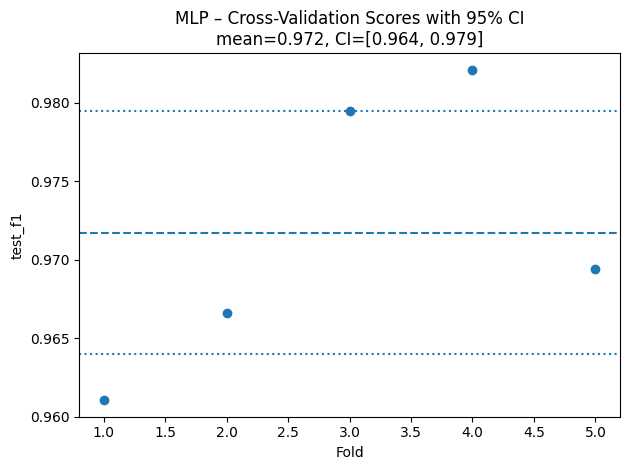

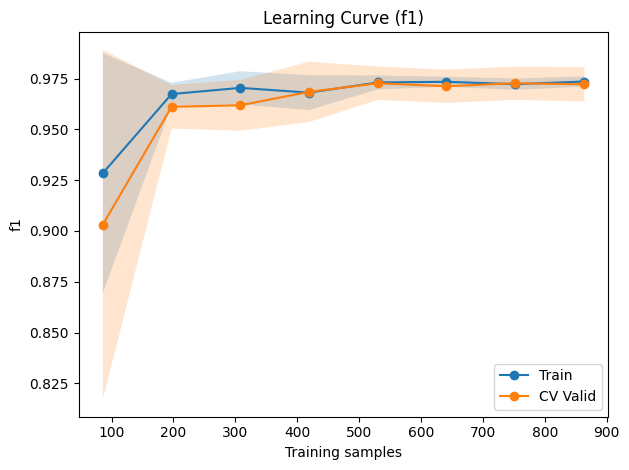


Saved to: mlp_final_pipeline.joblib


In [96]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=2000,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42
)

fit_and_save_final_model(Final_yf_full, mlp_model, "mlp_final_pipeline.joblib")

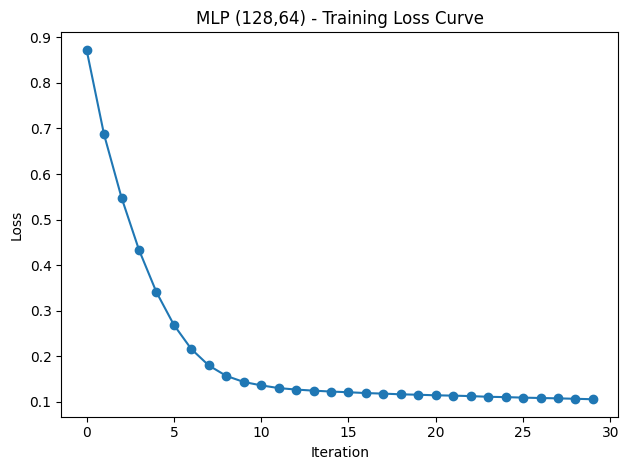

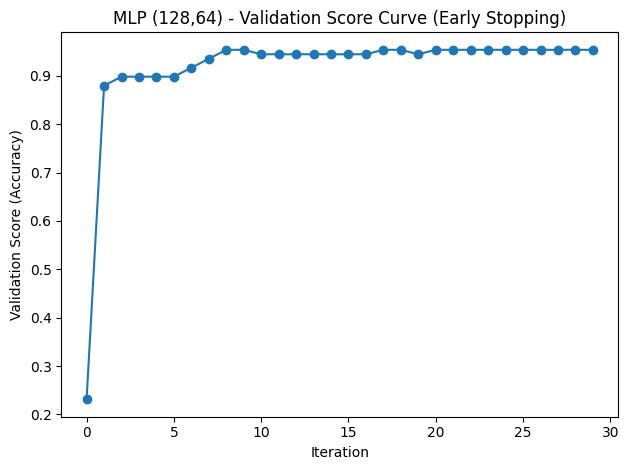

[Validation] best=0.9537 at iter=9, last=0.9537, gap(best-last)=0.0000
[Training] n_iter_ actually used: 30
[Training] best_loss_ not available (None).


In [97]:
import numpy as np
import matplotlib.pyplot as plt
from joblib import load

def plot_mlp_training_curves(joblib_path: str, title_prefix="MLP"):
    payload = load(joblib_path)
    pipe = payload["pipeline"]
    mlp = pipe.named_steps["model"]

    # ---------------------------
    # 1) Loss curve
    # ---------------------------
    if hasattr(mlp, "loss_curve_") and mlp.loss_curve_ is not None:
        plt.figure()
        plt.plot(mlp.loss_curve_, marker="o")
        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        plt.title(f"{title_prefix} - Training Loss Curve")
        plt.tight_layout()
        plt.show()
    else:
        print("No loss_curve_ available.")

    # ---------------------------
    # 2) Validation curve (early stopping)
    # ---------------------------
    if hasattr(mlp, "validation_scores_") and mlp.validation_scores_ is not None:
        scores = np.array(mlp.validation_scores_)

        plt.figure()
        plt.plot(scores, marker="o")
        plt.xlabel("Iteration")
        plt.ylabel("Validation Score (Accuracy)")
        plt.title(f"{title_prefix} - Validation Score Curve (Early Stopping)")
        plt.tight_layout()
        plt.show()

        best = scores.max()
        best_iter = int(scores.argmax()) + 1
        last = scores[-1]

        print(
            f"[Validation] best={best:.4f} at iter={best_iter}, "
            f"last={last:.4f}, gap(best-last)={best-last:.4f}"
        )
    else:
        print("No validation_scores_ available (early_stopping may be False).")

    # ---------------------------
    # 3) Iteration info
    # ---------------------------
    if hasattr(mlp, "n_iter_"):
        print(f"[Training] n_iter_ actually used: {mlp.n_iter_}")

    if hasattr(mlp, "best_loss_") and mlp.best_loss_ is not None:
        print(f"[Training] best_loss_: {mlp.best_loss_:.6f}")
    else:
        print("[Training] best_loss_ not available (None).")

# 사용 예시
plot_mlp_training_curves("mlp_final_pipeline.joblib", title_prefix="MLP (128,64)")

## Bootsampling(Class Imbalance)

In [102]:
from joblib import load

def load_pipeline(save_path: str):
    payload = load(save_path)
    return payload["pipeline"], payload

rf_pipe, rf_meta = load_pipeline("rf_final_pipeline.joblib")
gb_pipe, gb_meta = load_pipeline("gb_final_pipeline.joblib")
mlp_pipe, mlp_meta = load_pipeline("mlp_final_pipeline.joblib")

In [105]:
os.makedirs('Experiment_results_400', exist_ok=True)
# os.makedirs('Experiment_results_shuffle', exist_ok=True)

In [106]:
Random_forest_list = []
# Placeholders for additional models
Gradient_boosting_list = []
MLP_list = []
sample_ratios = [1, 0.1, 0.01]
for b in notebook.tqdm(range(1000), desc='bootstrap') :
    for sample_ratio in sample_ratios :
        new_raw_df = make_Final_yf(yf=yf, NF=NF, english_cols=english_cols, sample_ratio=sample_ratio, seed=b)
        # shuffled_df = new_raw_df.sample(frac=1, random_state=42).reset_index(drop=True)
        y_true = new_raw_df.pop("Label").to_numpy()
        # y_true = shuffled_df.pop("Label").to_numpy()
        rf_pred = rf_pipe.predict(new_raw_df) 
        gb_pred = gb_pipe.predict(new_raw_df) 
        mlp_pred = mlp_pipe.predict(new_raw_df) 
        # rf_pred = rf_pipe.predict(shuffled_df) 
        # gb_pred = gb_pipe.predict(shuffled_df) 
        # mlp_pred = mlp_pipe.predict(shuffled_df) 
        tn, fp, fn, tp = confusion_matrix(y_true, rf_pred).ravel()
        report = classification_report(y_true, rf_pred, output_dict=True)
        # 3. Build your custom dictionary
        result_dict = {
            'TN': tn,
            'FP': fp,
            'FN': fn,
            'TP': tp,
            'Accuracy': round(report['accuracy'], 3),
            'Precision of class1': round(report['1']['precision'], 3),
            'Recall of class1': round(report['1']['recall'], 3),
            'F1-score': round(report['1']['f1-score'], 3),
            'Sample_Ratio' : sample_ratio
        }
        Random_forest_list.append(result_dict)
    
        tn, fp, fn, tp = confusion_matrix(y_true, gb_pred).ravel()
        report = classification_report(y_true, gb_pred, output_dict=True)
        # 3. Build your custom dictionary
        result_dict = {
            'TN': tn,
            'FP': fp,
            'FN': fn,
            'TP': tp,
            'Accuracy': round(report['accuracy'], 3),
            'Precision of class1': round(report['1']['precision'], 3),
            'Recall of class1': round(report['1']['recall'], 3),
            'F1-score': round(report['1']['f1-score'], 3),
            'Sample_Ratio' : sample_ratio
        }
        Gradient_boosting_list.append(result_dict)
    
        tn, fp, fn, tp = confusion_matrix(y_true, mlp_pred).ravel()
        report = classification_report(y_true, mlp_pred, output_dict=True)
        # 3. Build your custom dictionary
        result_dict = {
            'TN': tn,
            'FP': fp,
            'FN': fn,
            'TP': tp,
            'Accuracy': round(report['accuracy'], 3),
            'Precision of class1': round(report['1']['precision'], 3),
            'Recall of class1': round(report['1']['recall'], 3),
            'F1-score': round(report['1']['f1-score'], 3),
            'Sample_Ratio' : sample_ratio
        }
        MLP_list.append(result_dict)

Random_forest_df = pd.DataFrame(Random_forest_list)
Gradient_boosting_df = pd.DataFrame(Gradient_boosting_list)
MLP_df = pd.DataFrame(MLP_list)
Random_forest_df['Remarks'] =  f'{threshold_duration}day'
Gradient_boosting_df['Remarks'] =  f'{threshold_duration}day'
MLP_df['Remarks'] =  f'{threshold_duration}day'
Random_forest_df.to_excel(f'./Experiment_results_400/Random_forest_results_{threshold_durations}day_sample_Ratios.xlsx', index=False)
Gradient_boosting_df.to_excel(f'./Experiment_results_400/Gradient_boosting_results_{threshold_durations}day_sample_Ratios.xlsx', index=False)
MLP_df.to_excel(f'./Experiment_results_400/MLP_df_{threshold_durations}day_sample_Ratios.xlsx', index=False)    

bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]


KeyboardInterrupt



## Visualization

In [107]:
file_names = os.listdir('Experiment_results_400/')

In [109]:
folder = 'Experiment_results_400'

In [111]:
Random_forest_file_paths = []
for file in file_names :
    file_path_ref = os.path.join(folder, file)
    # if 'Random_forest' in file_path_ref : 
    if 'Random_forest' in file_path_ref and 'sample_Ratios' in file_path_ref:
        Random_forest_file_paths.append(file_path_ref)
rf_dfs = pd.DataFrame()
for file_path in Random_forest_file_paths :
    temp = pd.read_excel(file_path)
    rf_dfs = pd.concat([rf_dfs, temp], ignore_index=True)

main_list = []
sample_ratios = rf_dfs['Sample_Ratio'].unique()

for sample_ratio in sample_ratios:
    temp = rf_dfs[rf_dfs['Sample_Ratio'] == sample_ratio]

    # mean
    mean_vals = temp.mean(numeric_only=True)

    # std (표본 표준편차)
    std_vals = temp.std(numeric_only=True)

    result = {}

    # mean ± sd 형태로 만들기
    for col in ['F1-score', 'Accuracy', 'Precision of class1', 'Recall of class1']:
        result[col] = f"{mean_vals[col]:.3f} ± {std_vals[col]:.3f}"

    result['Sample_Ratio'] = f"{sample_ratio}"
    result['Remarks'] = 'Random Forest'

    main_list.append(result)

rf_result_df = pd.DataFrame(main_list)
rf_result_df = rf_result_df.sort_values('Sample_Ratio', ignore_index=True)

In [112]:
Gradient_boosting_file_paths = []
for file in file_names :
    file_path_ref = os.path.join(folder, file)
    # if 'Gradient_boosting' in file_path_ref :
    if 'Gradient_boosting' in file_path_ref and 'sample_Ratios' in file_path_ref:
        Gradient_boosting_file_paths.append(file_path_ref)
Gb_dfs = pd.DataFrame()
for file_path in Gradient_boosting_file_paths :
    temp = pd.read_excel(file_path)
    Gb_dfs = pd.concat([Gb_dfs, temp], ignore_index=True)   
main_list = []
sample_ratios = Gb_dfs['Sample_Ratio'].unique()
for sample_ratio in sample_ratios :
    temp = Gb_dfs[Gb_dfs['Sample_Ratio'] == sample_ratio]
    # print(duration)
    temp = temp.drop(columns = 'Remarks')
    temp_dic = temp.mean().to_dict()
    temp_dic['Sample_Ratio'] =f'{sample_ratio}'
    main_list.append(temp_dic)
Gb_result_df = pd.DataFrame(main_list)
# rf_result_df['Duration'] = rf_result_df['Duration'].str.replace('day','').astype('int')
Gb_result_df = Gb_result_df.sort_values('Sample_Ratio', ignore_index=True)
# plot_duration_performance(Gb_result_df, "Gradient_boosting")
Gb_result_df['Remarks'] = 'Gradient_boosting'

main_list = []
sample_ratios = Gb_dfs['Sample_Ratio'].unique()

for sample_ratio in sample_ratios:
    temp = Gb_dfs[Gb_dfs['Sample_Ratio'] == sample_ratio]

    # mean
    mean_vals = temp.mean(numeric_only=True)

    # std (표본 표준편차)
    std_vals = temp.std(numeric_only=True)

    result = {}

    # mean ± sd 형태로 만들기
    for col in ['F1-score', 'Accuracy', 'Precision of class1', 'Recall of class1']:
        result[col] = f"{mean_vals[col]:.3f} ± {std_vals[col]:.3f}"

    result['Sample_Ratio'] = f"{sample_ratio}"
    result['Remarks'] = 'Gradient_boosting'

    main_list.append(result)

Gb_result_df = pd.DataFrame(main_list)
Gb_result_df = Gb_result_df.sort_values('Sample_Ratio', ignore_index=True)

In [113]:
MLP_file_paths = []
for file in file_names :
    file_path_ref = os.path.join(folder, file)
    # if 'MLP' in file_path_ref :
    if 'MLP' in file_path_ref and 'sample_Ratios' in file_path_ref:
        MLP_file_paths.append(file_path_ref)
MLP_dfs = pd.DataFrame()
for file_path in MLP_file_paths :
    temp = pd.read_excel(file_path)
    MLP_dfs = pd.concat([MLP_dfs, temp], ignore_index=True)   
main_list = []
sample_ratios = rf_dfs['Sample_Ratio'].unique()
for sample_ratio in sample_ratios :
    temp = MLP_dfs[MLP_dfs['Sample_Ratio'] == sample_ratio]
    # print(duration)
    temp = temp.drop(columns = 'Remarks')
    temp_dic = temp.mean().to_dict()
    temp_dic['Sample_Ratio'] =f'{sample_ratio}'
    main_list.append(temp_dic)
MLP_result_df = pd.DataFrame(main_list)
# rf_result_df['Duration'] = rf_result_df['Duration'].str.replace('day','').astype('int')
MLP_result_df = MLP_result_df.sort_values('Sample_Ratio', ignore_index=True)
# plot_duration_performance(Gb_result_df, "Gradient_boosting")
MLP_result_df['Remarks'] = 'MLP'

main_list = []
sample_ratios = MLP_dfs['Sample_Ratio'].unique()

for sample_ratio in sample_ratios:
    temp = MLP_dfs[MLP_dfs['Sample_Ratio'] == sample_ratio]

    # mean
    mean_vals = temp.mean(numeric_only=True)

    # std (표본 표준편차)
    std_vals = temp.std(numeric_only=True)

    result = {}

    # mean ± sd 형태로 만들기
    for col in ['F1-score', 'Accuracy', 'Precision of class1', 'Recall of class1']:
        result[col] = f"{mean_vals[col]:.3f} ± {std_vals[col]:.3f}"

    result['Sample_Ratio'] = f"{sample_ratio}"
    result['Remarks'] = 'MLP'

    main_list.append(result)

MLP_result_df = pd.DataFrame(main_list)
MLP_result_df = MLP_result_df.sort_values('Sample_Ratio', ignore_index=True)

In [115]:
rf_result_df["Remarks"] = 'Random forest'
Gb_result_df["Remarks"] = 'Gradient_boosting'
MLP_result_df["Remarks"] = 'MLP'
total_result_df = pd.concat([rf_result_df,Gb_result_df,MLP_result_df], ignore_index=True)
total_result_df

,F1-score,Accuracy,Precision of class1,Recall of class1,Sample_Ratio,Remarks
0,0.988 ± 0.109,1.000 ± 0.001,0.988 ± 0.109,0.988 ± 0.109,0.01,Random forest
1,0.995 ± 0.016,0.999 ± 0.003,1.000 ± 0.000,0.991 ± 0.029,0.1,Random forest
2,0.995 ± 0.005,0.995 ± 0.005,1.000 ± 0.000,0.990 ± 0.010,1.0,Random forest
3,0.944 ± 0.230,0.999 ± 0.002,0.944 ± 0.230,0.944 ± 0.230,0.01,Gradient_boosting
4,0.971 ± 0.037,0.995 ± 0.006,1.000 ± 0.000,0.946 ± 0.067,0.1,Gradient_boosting
5,0.973 ± 0.011,0.974 ± 0.010,1.000 ± 0.000,0.947 ± 0.020,1.0,Gradient_boosting
6,0.417 ± 0.186,0.980 ± 0.004,0.278 ± 0.124,0.834 ± 0.372,0.01,MLP
7,0.830 ± 0.066,0.969 ± 0.010,0.821 ± 0.021,0.845 ± 0.111,0.1,MLP
8,0.905 ± 0.020,0.912 ± 0.017,0.978 ± 0.001,0.842 ± 0.035,1.0,MLP


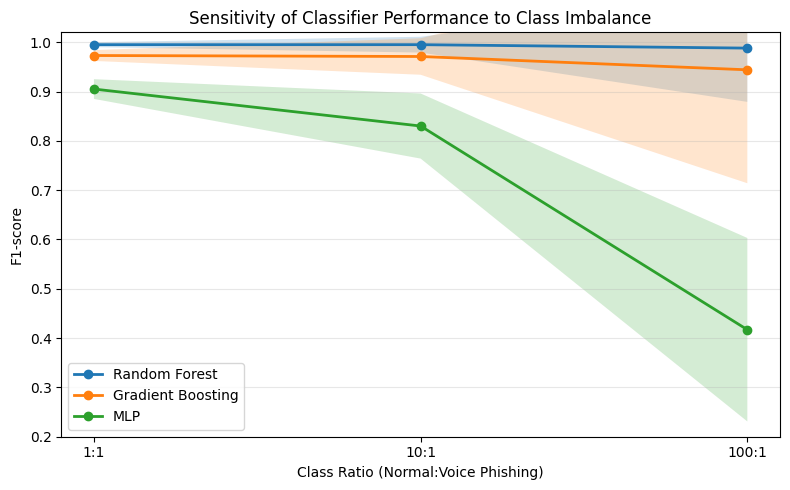

In [116]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 데이터 입력
plot_df = pd.DataFrame({
    "Sample_Ratio": [1.0, 0.1, 0.01],
    "Ratio_Label": ["1:1", "10:1", "100:1"],

    "RF_mean": [0.995, 0.995, 0.988],
    "RF_sd":   [0.005, 0.016, 0.109],

    "GB_mean": [0.973, 0.971, 0.944],
    "GB_sd":   [0.011, 0.037, 0.230],

    "MLP_mean": [0.905, 0.830, 0.417],
    "MLP_sd":   [0.020, 0.066, 0.186],
})

# x축 순서: 1:1 -> 10:1 -> 100:1
plot_df = plot_df.sort_values("Sample_Ratio", ascending=False).reset_index(drop=True)
x = np.arange(len(plot_df))

plt.figure(figsize=(8, 5))

# Random Forest
plt.plot(x, plot_df["RF_mean"], marker="o", linewidth=2, label="Random Forest")
plt.fill_between(
    x,
    plot_df["RF_mean"] - plot_df["RF_sd"],
    plot_df["RF_mean"] + plot_df["RF_sd"],
    alpha=0.2
)

# Gradient Boosting
plt.plot(x, plot_df["GB_mean"], marker="o", linewidth=2, label="Gradient Boosting")
plt.fill_between(
    x,
    plot_df["GB_mean"] - plot_df["GB_sd"],
    plot_df["GB_mean"] + plot_df["GB_sd"],
    alpha=0.2
)

# MLP
plt.plot(x, plot_df["MLP_mean"], marker="o", linewidth=2, label="MLP")
plt.fill_between(
    x,
    plot_df["MLP_mean"] - plot_df["MLP_sd"],
    plot_df["MLP_mean"] + plot_df["MLP_sd"],
    alpha=0.2
)

plt.xticks(x, plot_df["Ratio_Label"])
plt.ylabel("F1-score")
plt.xlabel("Class Ratio (Normal:Voice Phishing)")
plt.title("Sensitivity of Classifier Performance to Class Imbalance")
plt.ylim(0.2, 1.02)
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("class_imbalance_sensitivity_f1.png", dpi=300, bbox_inches="tight")
plt.show()